In [55]:

import pandas

data = pandas.read_csv("khl_matches.csv")

if "match_url" in data.columns:
    data = data.drop(columns=["match_url"])

rate_columns = [
    "home_shot_efficiency",
    "away_shot_efficiency",
    "home_faceoff_efficiency",
    "away_faceoff_efficiency",
    "attendance_rate"
]

print("Проверка корректности дробных признаков:")

for col in rate_columns:
    data[col] = pandas.to_numeric(data[col], errors="coerce")
    bad_values = data[(data[col] < 0) | (data[col] > 1) | (data[col].isna())]
    if bad_values.empty:
        print(f"{col}: все значения корректны")
    else:
        print(f"{col}: обнаружены некорректные значения - {len(bad_values)} строк:")
        with pandas.option_context(
            'display.max_rows', None,
            'display.max_columns', None,
            'display.width', None
        ):
            display(bad_values)

bad_cap_mask = data["capacity"] <= 1000

team_cap_median = (
    data.loc[~bad_cap_mask]
    .groupby("home_team")["capacity"]
    .median()
)

league_cap_median = data.loc[~bad_cap_mask, "capacity"].median()

def impute_capacity(row):
    cap = row["capacity"]
    if cap > 1000:
        return cap
    m = team_cap_median.get(row["home_team"], pandas.NA)
    if pandas.notna(m):
        return m
    return league_cap_median


data["capacity_fixed"] = data.apply(impute_capacity, axis=1)

data["attendance_rate"] = (
    data["attendance"] / data["capacity_fixed"]
).clip(lower=0, upper=1)

data["capacity"] = data["capacity_fixed"]
data = data.drop(columns=["capacity_fixed"])

numeric_for_outliers = [
    "attendance",
    "capacity"
]

for col in numeric_for_outliers:
    q_min = data[col].quantile(0.01)
    q_max = data[col].quantile(0.99)
    data[col] = data[col].clip(lower=q_min, upper=q_max)

print("Выполнено отсечение выбросов для показателей посещаемости и вместимости")

print("Форма датасета:")
print(data.shape)
print("Типы данных:")
print(data.dtypes)
print("Количество пропусков по столбцам:")
print(data.isna().sum())

data.head(10)


Проверка корректности дробных признаков:
home_shot_efficiency: все значения корректны
away_shot_efficiency: все значения корректны
home_faceoff_efficiency: все значения корректны
away_faceoff_efficiency: все значения корректны
attendance_rate: обнаружены некорректные значения - 46 строк:


,home_team,away_team,home_goals,away_goals,home_shots,away_shots,home_shot_efficiency,away_shot_efficiency,home_faceoffs,away_faceoffs,home_faceoff_efficiency,away_faceoff_efficiency,attendance,capacity,attendance_rate,home_win
7,Витязь,Авангард,3,2,22,39,0.136364,0.051282,25,23,0.520833,0.479167,5700,5525,1.031674,1
202,Трактор,Ак Барс,5,2,51,20,0.098039,0.100000,34,31,0.523077,0.476923,7501,7500,1.000133,1
515,Салават Юлаев,СКА,5,1,26,27,0.192308,0.037037,33,29,0.532258,0.467742,8550,8522,1.003286,1
599,Салават Юлаев,Ак Барс,0,0,36,22,0.000000,0.000000,26,30,0.464286,0.535714,8550,8522,1.003286,0
910,Металлург Мг,Салават Юлаев,6,3,32,29,0.187500,0.103448,21,31,0.403846,0.596154,7777,7700,1.010000,1
981,Адмирал,Спартак,3,4,27,44,0.111111,0.090909,31,29,0.516667,0.483333,5915,1,5915.000000,0
1010,Амур,Витязь,4,2,33,25,0.121212,0.080000,22,36,0.379310,0.620690,7100,1,7100.000000,1
1011,Сибирь,ЦСКА,3,6,25,40,0.120000,0.150000,20,34,0.370370,0.629630,10587,1,10587.000000,0
1026,Динамо Мн,Северсталь,1,2,35,22,0.028571,0.090909,41,35,0.539474,0.460526,15266,1,15266.000000,0
1027,ХК Сочи,Динамо М,2,5,40,30,0.050000,0.166667,37,36,0.506849,0.493151,12000,1,12000.000000,0


Выполнено отсечение выбросов для показателей посещаемости и вместимости
Форма датасета:
(2311, 16)
Типы данных:
home_team                   object
away_team                   object
home_goals                   int64
away_goals                   int64
home_shots                   int64
away_shots                   int64
home_shot_efficiency       float64
away_shot_efficiency       float64
home_faceoffs                int64
away_faceoffs                int64
home_faceoff_efficiency    float64
away_faceoff_efficiency    float64
attendance                 float64
capacity                   float64
attendance_rate            float64
home_win                     int64
dtype: object
Количество пропусков по столбцам:
home_team                  0
away_team                  0
home_goals                 0
away_goals                 0
home_shots                 0
away_shots                 0
home_shot_efficiency       0
away_shot_efficiency       0
home_faceoffs              0
away_faceoffs      

,home_team,away_team,home_goals,away_goals,home_shots,away_shots,home_shot_efficiency,away_shot_efficiency,home_faceoffs,away_faceoffs,home_faceoff_efficiency,away_faceoff_efficiency,attendance,capacity,attendance_rate,home_win
0,ЦСКА,Металлург Мг,6,2,34,27,0.176471,0.074074,29,31,0.483333,0.516667,7337.0,12680.0,0.578628,1
1,Автомобилист,Локомотив,4,2,26,20,0.153846,0.100000,35,25,0.583333,0.416667,2869.0,5570.0,0.515081,1
2,Трактор,Северсталь,2,4,30,18,0.066667,0.222222,24,20,0.545455,0.454545,5820.0,7500.0,0.776000,0
3,Куньлунь Ред Стар,Адмирал,3,1,22,30,0.136364,0.033333,40,17,0.701754,0.298246,598.5,7000.0,0.070000,1
4,Спартак,Амур,3,2,29,30,0.103448,0.066667,28,32,0.466667,0.533333,2512.0,12724.0,0.197422,1
5,ХК Сочи,Сибирь,0,2,31,29,0.000000,0.068966,22,36,0.379310,0.620690,3048.0,12000.0,0.254000,0
6,Динамо М,Ак Барс,2,0,25,24,0.080000,0.000000,24,24,0.500000,0.500000,5432.0,11500.0,0.472348,1
7,Витязь,Авангард,3,2,22,39,0.136364,0.051282,25,23,0.520833,0.479167,5700.0,5525.0,1.000000,1
8,Динамо Мн,Барыс,4,3,31,25,0.129032,0.120000,30,41,0.422535,0.577465,13805.0,15266.0,0.904297,1
9,СКА,Салават Юлаев,0,0,40,28,0.000000,0.000000,36,20,0.642857,0.357143,12228.0,12500.0,0.978240,0


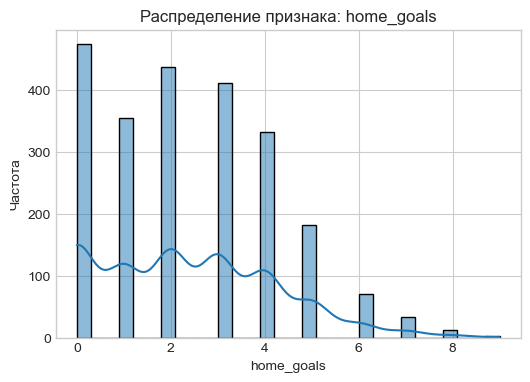

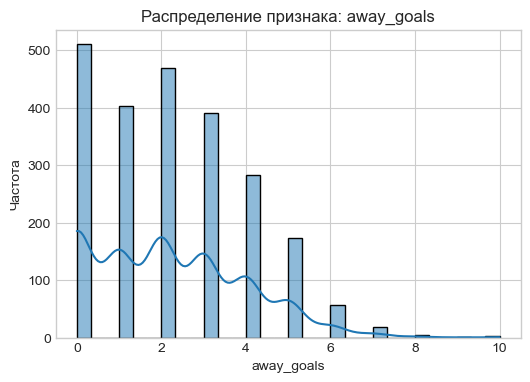

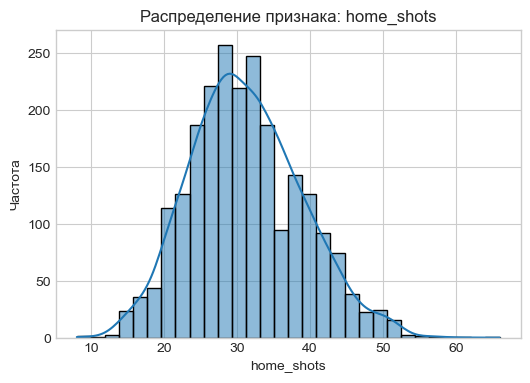

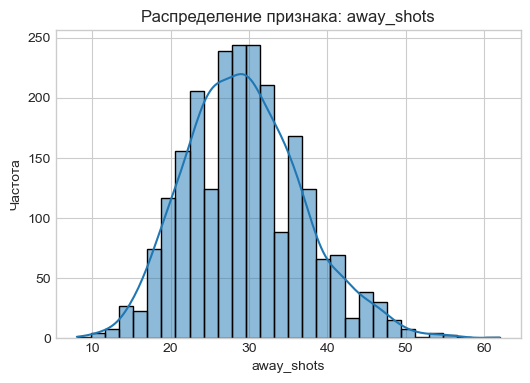

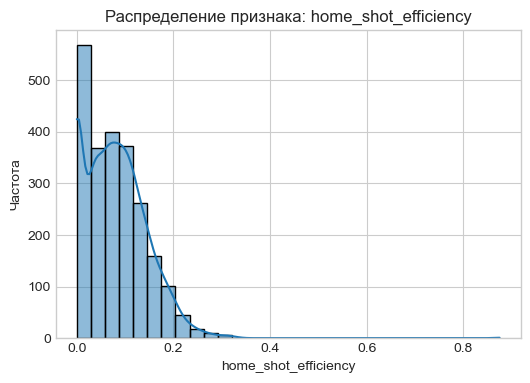

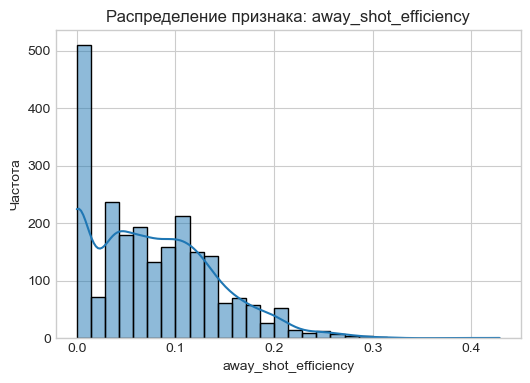

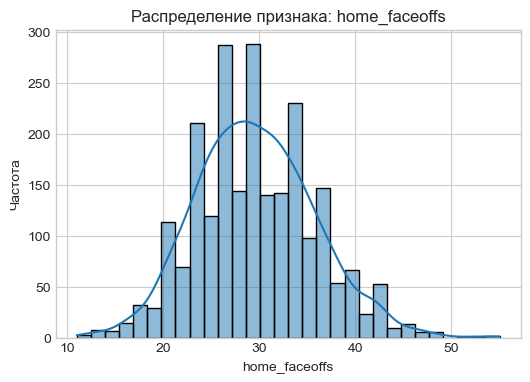

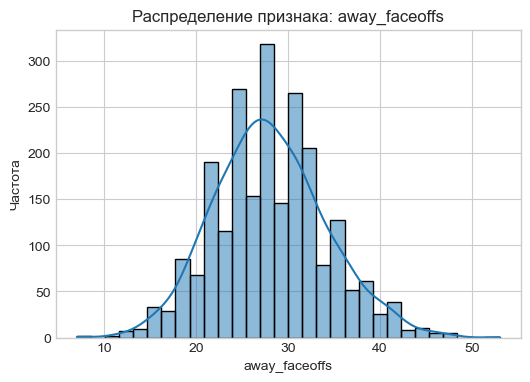

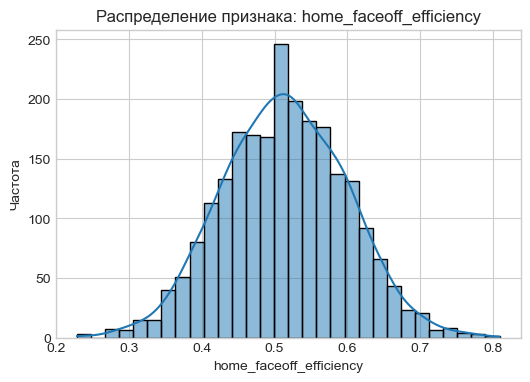

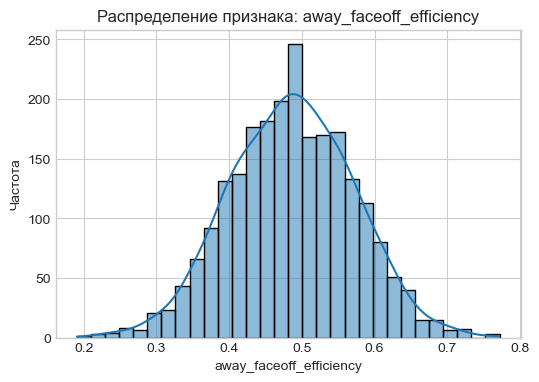

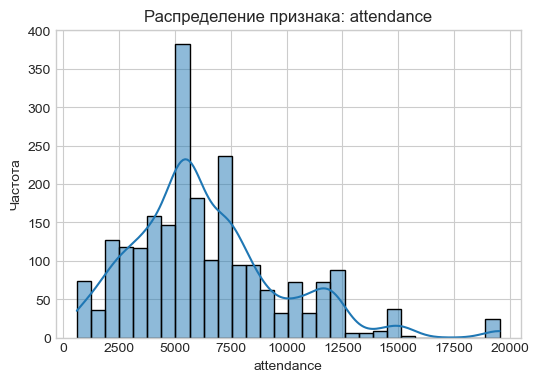

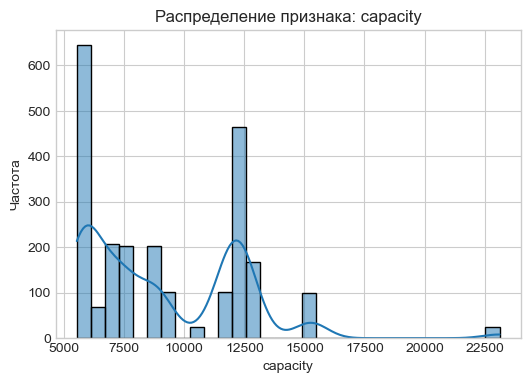

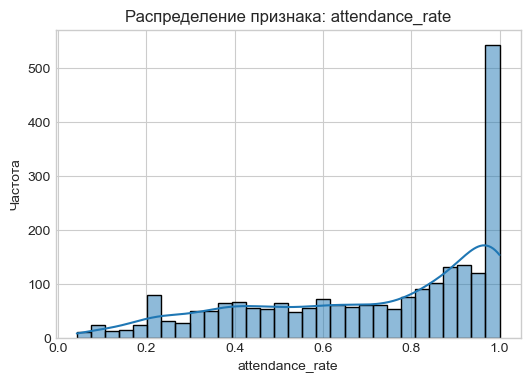

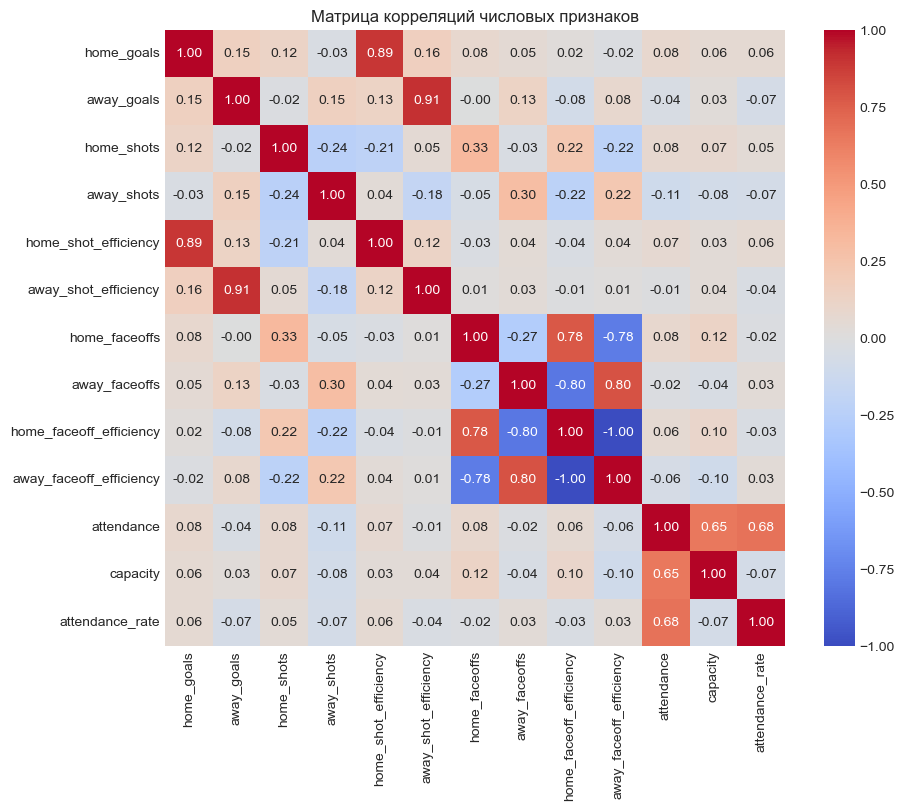

In [56]:
import matplotlib.pyplot as plt
import seaborn

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)
numeric_cols = [
    "home_goals", "away_goals",
    "home_shots", "away_shots",
    "home_shot_efficiency", "away_shot_efficiency",
    "home_faceoffs", "away_faceoffs",
    "home_faceoff_efficiency", "away_faceoff_efficiency",
    "attendance", "capacity", "attendance_rate"
]

for col in numeric_cols:
    plt.figure()
    seaborn.histplot(data[col], bins=30, kde=True)
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.show()

corr = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
seaborn.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Матрица корреляций числовых признаков")
plt.show()




In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "home_shots", "away_shots",
    "home_faceoffs", "away_faceoffs",
    "home_faceoff_efficiency", "away_faceoff_efficiency",
    "attendance", "capacity", "attendance_rate"
]

categorical_cols = ["home_team", "away_team"]
team_dummies = pandas.get_dummies(
    data[categorical_cols],
    prefix=["home", "away"],
    dtype=int
)

X_numeric = data[feature_cols].reset_index(drop=True)
X = pandas.concat([X_numeric, team_dummies.reset_index(drop=True)], axis=1)
y = data["home_win"]

print("Количество признаков после кодирования:", X.shape[1])
print("Форма X:", X.shape)
print("Форма y:", y.shape)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Размер train:", X_train.shape, y_train.shape)
print("Размер val:", X_val.shape, y_val.shape)
print("Размер test:", X_test.shape, y_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Количество признаков после кодирования: 55
Форма X: (2311, 55)
Форма y: (2311,)
Размер train: (1617, 55) (1617,)
Размер val: (347, 55) (347,)
Размер test: (347, 55) (347,)


In [58]:
from sklearn.metrics import accuracy_score

majority_class = y_train.value_counts().idxmax()
print("Самый частый результат (train):", majority_class)

baseline_predictions_train = [majority_class] * len(y_train)
baseline_predictions_val = [majority_class] * len(y_val)
baseline_predictions_test = [majority_class] * len(y_test)

train_baseline_acc = accuracy_score(y_train, baseline_predictions_train)
val_baseline_acc = accuracy_score(y_val, baseline_predictions_val)
test_baseline_acc = accuracy_score(y_test, baseline_predictions_test)

print("Точность baseline (train):", train_baseline_acc)
print("Точность baseline (val):", val_baseline_acc)
print("Точность baseline (test):", test_baseline_acc)

Самый частый результат (train): 0
Точность baseline (train): 0.5324675324675324
Точность baseline (val): 0.5302593659942363
Точность baseline (test): 0.5331412103746398


In [59]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

results = []

C_values = [0.01, 0.1, 1.0, 10.0]
iter_values = [200, 500, 1000, 2000]

for C in C_values:
    for it in iter_values:
        model = LogisticRegression(
            C=C,
            max_iter=it,
            penalty="l2",
            solver="liblinear"
        )

        model.fit(X_train_scaled, y_train)

        y_pred_val = model.predict(X_val_scaled)
        acc_val = accuracy_score(y_val, y_pred_val)

        results.append((C, it, acc_val))

print("Результаты подбора гиперпараметров:")
for C, it, acc in results:
    print(f"C={C}, max_iter={it} → val_accuracy={acc:.4f}")

best_C, best_iter, best_acc = max(results, key=lambda x: x[2])

print("Лучшие параметры:")
print(f"C={best_C}, max_iter={best_iter}, accuracy={best_acc:.4f}")


Результаты подбора гиперпараметров:
C=0.01, max_iter=200 → val_accuracy=0.6311
C=0.01, max_iter=500 → val_accuracy=0.6311
C=0.01, max_iter=1000 → val_accuracy=0.6311
C=0.01, max_iter=2000 → val_accuracy=0.6311
C=0.1, max_iter=200 → val_accuracy=0.6196
C=0.1, max_iter=500 → val_accuracy=0.6196
C=0.1, max_iter=1000 → val_accuracy=0.6196
C=0.1, max_iter=2000 → val_accuracy=0.6196
C=1.0, max_iter=200 → val_accuracy=0.6138
C=1.0, max_iter=500 → val_accuracy=0.6138
C=1.0, max_iter=1000 → val_accuracy=0.6138
C=1.0, max_iter=2000 → val_accuracy=0.6138
C=10.0, max_iter=200 → val_accuracy=0.6138
C=10.0, max_iter=500 → val_accuracy=0.6138
C=10.0, max_iter=1000 → val_accuracy=0.6138
C=10.0, max_iter=2000 → val_accuracy=0.6138
Лучшие параметры:
C=0.01, max_iter=200, accuracy=0.6311


In [60]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(f"Используем параметры C={best_C}, max_iter={best_iter}")

best_model = LogisticRegression(
    C=best_C,
    max_iter=best_iter,
    penalty="l2",
    solver="liblinear"
)

best_model.fit(X_train_scaled, y_train)
train_pred = best_model.predict(X_train_scaled)
train_acc_logreg = accuracy_score(y_train, train_pred)

val_pred = best_model.predict(X_val_scaled)
val_acc_logreg = accuracy_score(y_val, val_pred)

test_pred = best_model.predict(X_test_scaled)
test_acc_logreg = accuracy_score(y_test, test_pred)

print("Точность на train:", train_acc_logreg)
print("Точность на val:", val_acc_logreg)
print("Точность на test:", test_acc_logreg)

print("Матрица ошибок на test:")
print(confusion_matrix(y_test, test_pred))

print("Отчёт по классам:")
print(classification_report(y_test, test_pred))


Используем параметры C=0.01, max_iter=200
Точность на train: 0.6406926406926406
Точность на val: 0.6311239193083573
Точность на test: 0.5706051873198847
Матрица ошибок на test:
[[117  68]
 [ 81  81]]
Отчёт по классам:
              precision    recall  f1-score   support

           0       0.59      0.63      0.61       185
           1       0.54      0.50      0.52       162

    accuracy                           0.57       347
   macro avg       0.57      0.57      0.57       347
weighted avg       0.57      0.57      0.57       347



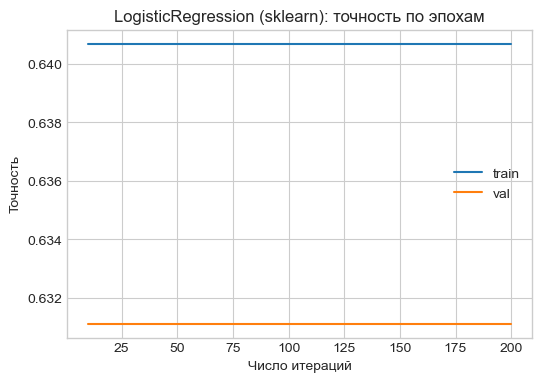

In [61]:

import warnings
from sklearn.exceptions import ConvergenceWarning

epoch_step = max(best_iter // 20, 1)
epoch_numbers = list(range(epoch_step, best_iter + epoch_step, epoch_step))

history_model = LogisticRegression(
    C=best_C,
    max_iter=epoch_step,
    penalty="l2",
    solver="liblinear",
    warm_start=True
)

train_acc_curve = []
val_acc_curve = []

for epoch in epoch_numbers:
    history_model.max_iter = epoch
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        history_model.fit(X_train_scaled, y_train)
    train_acc_curve.append(accuracy_score(y_train, history_model.predict(X_train_scaled)))
    val_acc_curve.append(accuracy_score(y_val, history_model.predict(X_val_scaled)))

plt.figure(figsize=(6, 4))
plt.plot(epoch_numbers, train_acc_curve, label="train")
plt.plot(epoch_numbers, val_acc_curve, label="val")
plt.title("LogisticRegression (sklearn): точность по эпохам")
plt.xlabel("Число итераций")
plt.ylabel("Точность")
plt.legend()
plt.show()


In [62]:
import numpy as np

class MyLogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000, reg=0.0):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.reg = reg
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.train_history = []
        self.val_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y, X_val=None, y_val=None):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []
        self.train_history = []
        self.val_history = []
        eps = 1e-8

        if X_val is not None and y_val is not None:
            X_val = np.array(X_val)
            y_val = np.array(y_val)

        for _ in range(self.epochs):
            linear = np.dot(X, self.weights) + self.bias
            probs = self.sigmoid(linear)

            dw = (1 / n_samples) * np.dot(X.T, (probs - y)) + self.reg * self.weights
            db = (1 / n_samples) * np.sum(probs - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = -np.mean(
                y * np.log(probs + eps) + (1 - y) * np.log(1 - probs + eps)
            ) + (self.reg / 2) * np.sum(self.weights ** 2)
            train_pred = (probs >= 0.5).astype(int)
            train_acc = np.mean(train_pred == y)

            self.loss_history.append(loss)
            self.train_history.append(train_acc)

            if X_val is not None and y_val is not None:
                val_pred = self.predict(X_val)
                val_acc = np.mean(val_pred == y_val)
                self.val_history.append(val_acc)

    def predict(self, X):
        X = np.array(X)
        linear = np.dot(X, self.weights) + self.bias
        probs = self.sigmoid(linear)
        return (probs >= 0.5).astype(int)


In [63]:
manual_results = []
learning_rates = [0.01, 0.05, 0.1]
reg_values = [0.0, 0.01]
epoch_values = [500, 1000]

for lr in learning_rates:
    for reg in reg_values:
        for epochs in epoch_values:
            manual_model = MyLogisticRegression(
                learning_rate=lr,
                epochs=epochs,
                reg=reg
            )
            manual_model.fit(X_train_scaled, y_train, X_val_scaled, y_val)
            val_pred = manual_model.predict(X_val_scaled)
            acc = accuracy_score(y_val, val_pred)
            manual_results.append((lr, reg, epochs, acc))
            print(f"lr={lr}, reg={reg}, epochs={epochs} → val_accuracy={acc:.4f}")

best_lr, best_reg, best_epochs, best_manual_acc = max(manual_results, key=lambda x: x[3])
print("Лучшие параметры:")
print(f"learning_rate={best_lr}, reg={best_reg}, epochs={best_epochs}, accuracy={best_manual_acc:.4f}")


lr=0.01, reg=0.0, epochs=500 → val_accuracy=0.6081
lr=0.01, reg=0.0, epochs=1000 → val_accuracy=0.6196
lr=0.01, reg=0.01, epochs=500 → val_accuracy=0.6110
lr=0.01, reg=0.01, epochs=1000 → val_accuracy=0.6254
lr=0.05, reg=0.0, epochs=500 → val_accuracy=0.6254
lr=0.05, reg=0.0, epochs=1000 → val_accuracy=0.6225
lr=0.05, reg=0.01, epochs=500 → val_accuracy=0.6282
lr=0.05, reg=0.01, epochs=1000 → val_accuracy=0.6254
lr=0.1, reg=0.0, epochs=500 → val_accuracy=0.6225
lr=0.1, reg=0.0, epochs=1000 → val_accuracy=0.6225
lr=0.1, reg=0.01, epochs=500 → val_accuracy=0.6254
lr=0.1, reg=0.01, epochs=1000 → val_accuracy=0.6282
Лучшие параметры:
learning_rate=0.05, reg=0.01, epochs=500, accuracy=0.6282


Точность на train: 0.6456400742115028
Точность на val: 0.6282420749279539
Точность на test: 0.5821325648414986


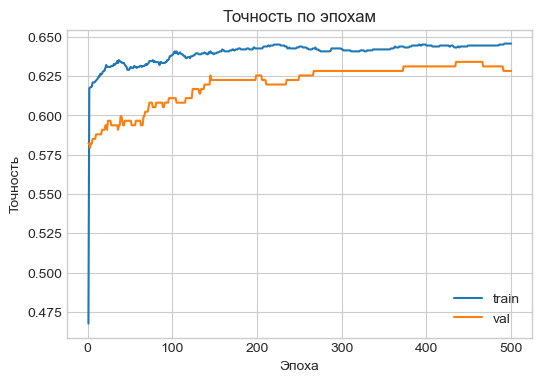

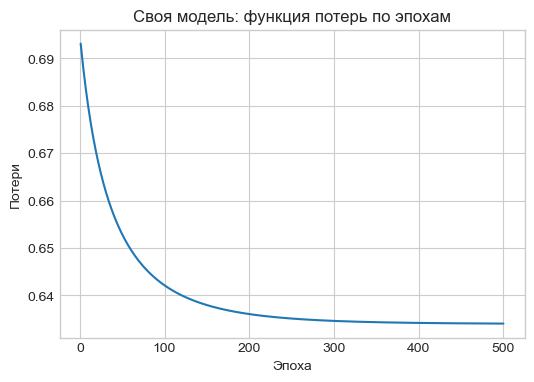

In [64]:
manual_best_model = MyLogisticRegression(
    learning_rate=best_lr,
    epochs=best_epochs,
    reg=best_reg
)

manual_best_model.fit(X_train_scaled, y_train, X_val_scaled, y_val)

train_pred_manual = manual_best_model.predict(X_train_scaled)
val_pred_manual = manual_best_model.predict(X_val_scaled)
test_pred_manual = manual_best_model.predict(X_test_scaled)

train_acc_manual = accuracy_score(y_train, train_pred_manual)
val_acc_manual = accuracy_score(y_val, val_pred_manual)
test_acc_manual = accuracy_score(y_test, test_pred_manual)

print("Точность на train:", train_acc_manual)
print("Точность на val:", val_acc_manual)
print("Точность на test:", test_acc_manual)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(manual_best_model.train_history) + 1), manual_best_model.train_history, label="train")
if manual_best_model.val_history:
    plt.plot(range(1, len(manual_best_model.val_history) + 1), manual_best_model.val_history, label="val")
plt.title("Точность по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Точность")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(manual_best_model.loss_history) + 1), manual_best_model.loss_history)
plt.title("Своя модель: функция потерь по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Потери")
plt.show()


In [65]:
comparison = pandas.DataFrame({
    "Модель": [
        "Baseline",
        "LogisticRegression",
        "My LogisticRegression"
    ],
    "Train accuracy": [
        train_baseline_acc,
        train_acc_logreg,
        train_acc_manual
    ],
    "Val accuracy": [
        val_baseline_acc,
        val_acc_logreg,
        val_acc_manual
    ],
    "Test accuracy": [
        test_baseline_acc,
        test_acc_logreg,
        test_acc_manual
    ]
})

print("Сравнение моделей по точности:")
display(comparison)



Сравнение моделей по точности:


,Модель,Train accuracy,Val accuracy,Test accuracy
0,Baseline,0.532468,0.530259,0.533141
1,LogisticRegression,0.640693,0.631124,0.570605
2,My LogisticRegression,0.645640,0.628242,0.582133
